In [2]:
!pip install shap

  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/a5/8e/cee1ee136a4e54fe2fbb63a60d72d7c25e21a4ffe6aa05779cab7669cb31/shap-0.51.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/c5/31/7fc6239c12bce7e931463251cca4426c465e1876ba3cc785402ef4dd8f4e/numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
  Obtaining dependency information for numba from https://files.pythonhosted.org/packages/5e/c9/9476940bc6d5caf5c0cf2e4c5feecbf01244bbe6f914614082dd7a3e520e/numba-0.66.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
langchain 0.0.313 requires numpy<2,>=1, but you have numpy 2.4.6 which is incompatible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/preprocessed_train.csv")

X = df.drop(columns="TARGET")
y = df["TARGET"]

X = pd.get_dummies(X, drop_first=True, dtype=int)

best_model = joblib.load("../models/best_model.pkl")

features = best_model.named_steps["imputer"].feature_names_in_
X = X.reindex(columns=features, fill_value=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 1. Financial Metrics

In [3]:
y_prob = best_model.predict_proba(X_test)[:, 1]

auroc = roc_auc_score(y_test, y_prob)
gini = 2 * auroc - 1
auprc = average_precision_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)
ks = max(tpr - fpr)

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = np.argmax(f1[:-1])

metrics = pd.DataFrame({
    "Metric": ["AUROC", "Gini", "KS", "AUPRC", "Best F1", "Optimal Threshold"],
    "Value": [auroc, gini, ks, auprc, f1[best_idx], thresholds[best_idx]]
})

metrics.round(4)

,Metric,Value
0,AUROC,0.7633
1,Gini,0.5265
2,KS,0.3893
3,AUPRC,0.2544
4,Best F1,0.3180
5,Optimal Threshold,0.1356


# 2. Cross-validation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring="roc_auc", n_jobs=1)

print("Fold scores:", cv_scores.round(4))
print("Mean AUROC:", cv_scores.mean().round(4))
print("Std AUROC:", cv_scores.std().round(4))

Fold scores: [0.7609 0.7691 0.7599 0.7692 0.7583]
Mean AUROC: 0.7635
Std AUROC: 0.0047


# 3. SHAP values and plots

In [6]:
imputer = best_model.named_steps["imputer"]
model = best_model.named_steps["model"]

X_test_imp = pd.DataFrame(imputer.transform(X_test),columns=X_test.columns,index=X_test.index)
X_shap = X_test_imp.sample(1000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_shap)

In [8]:
os.makedirs("../models", exist_ok=True)

np.save("../models/shap_values.npy", shap_values.values)
X_shap.to_csv("../models/shap_sample.csv", index=False)

## a) SHAP summary beeswarm plot

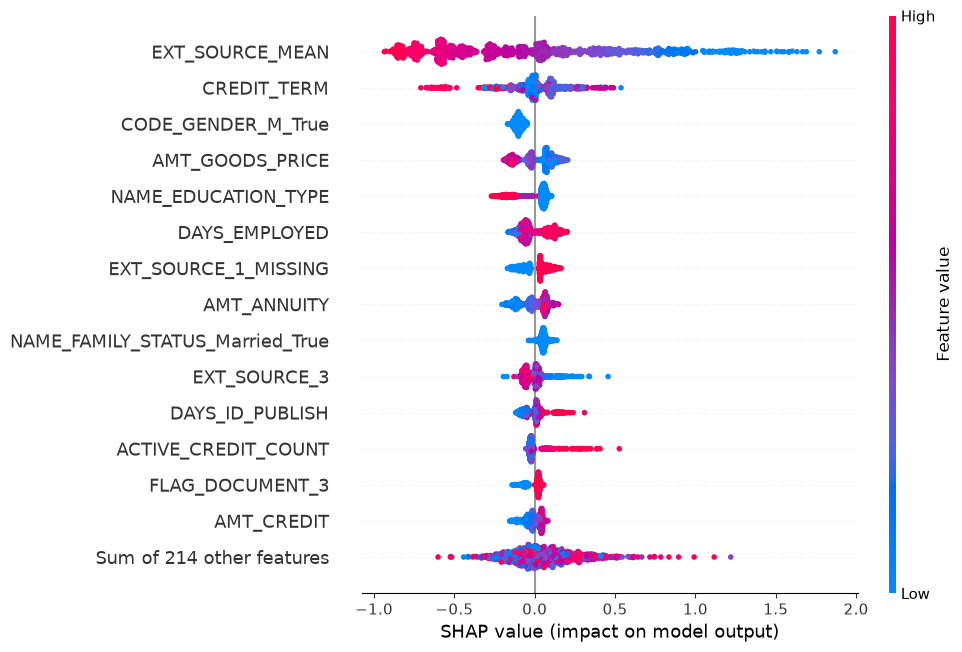

In [11]:
shap.plots.beeswarm(shap_values, max_display=15)

# (b) bar plot of mean |SHAP|

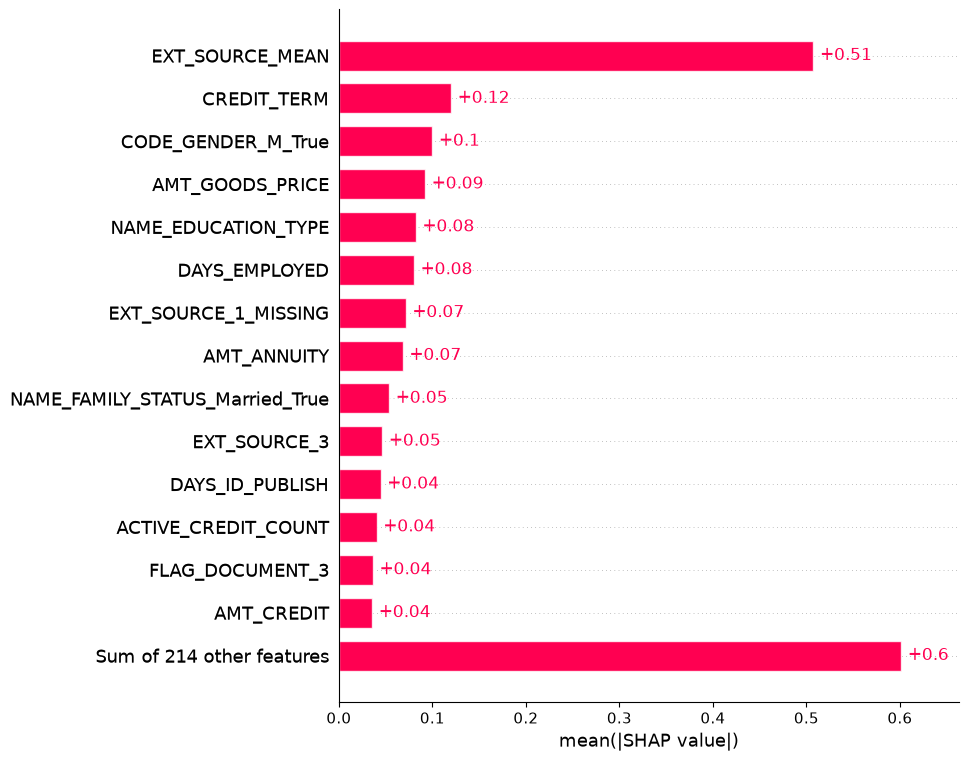

In [10]:
shap.plots.bar(shap_values, max_display=15)

# 4. Select 3 Individual Applicants And Waterfall Plots

In [26]:
risk = X_test_imp.copy()
risk["PD"] = y_prob

high_risk = risk[risk["PD"]>0.5].head(1)
borderline = risk[risk["PD"].between(0.2, 0.4)].head(1)
low_risk = risk[risk["PD"] < 0.1].head(1)

selected = pd.concat([high_risk.drop(columns="PD"), borderline.drop(columns="PD"), low_risk.drop(columns="PD")])

selected_shap = explainer(selected)

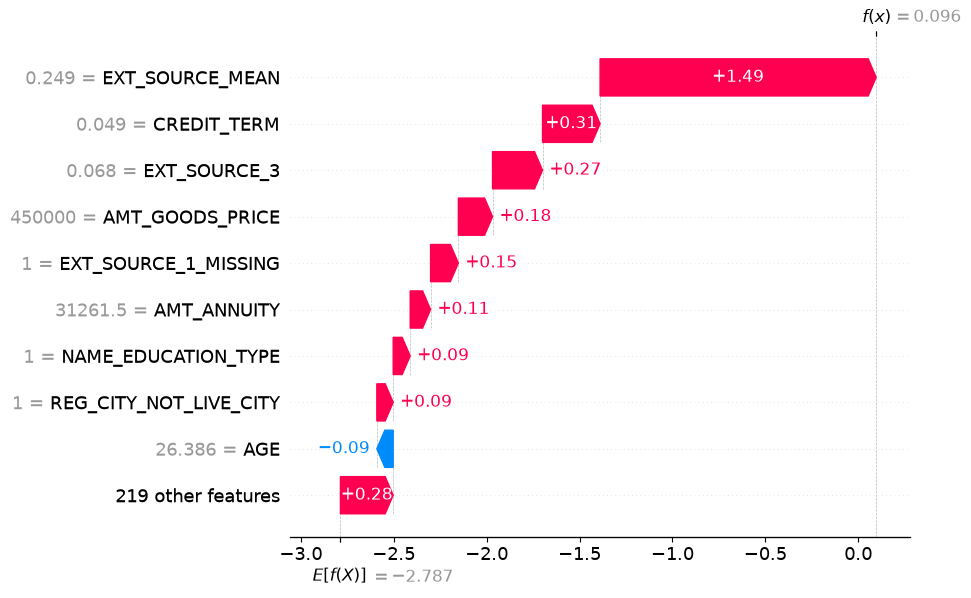

In [27]:
shap.plots.waterfall(selected_shap[0], max_display=10)

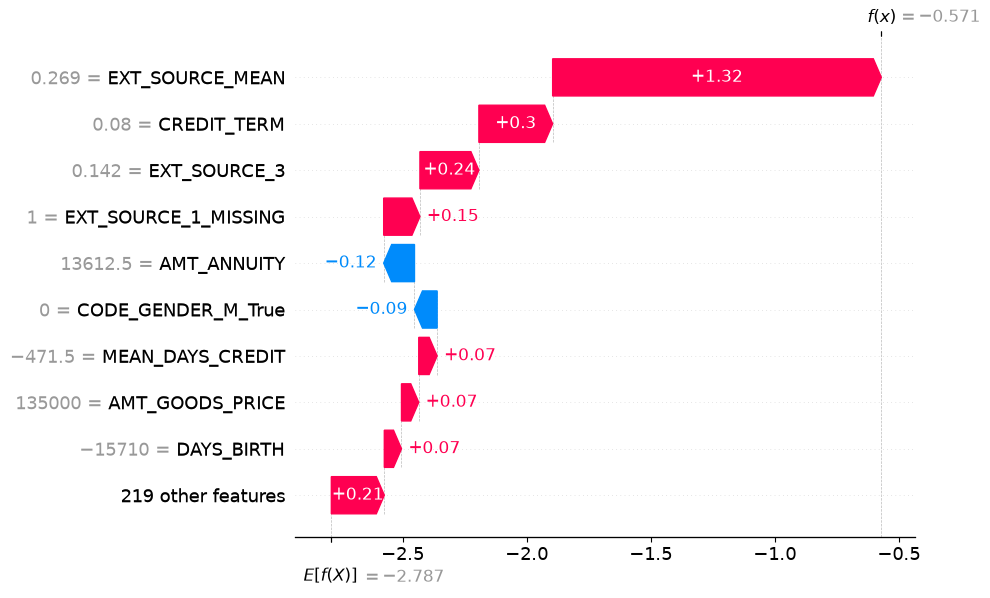

In [28]:
shap.plots.waterfall(selected_shap[1], max_display=10)

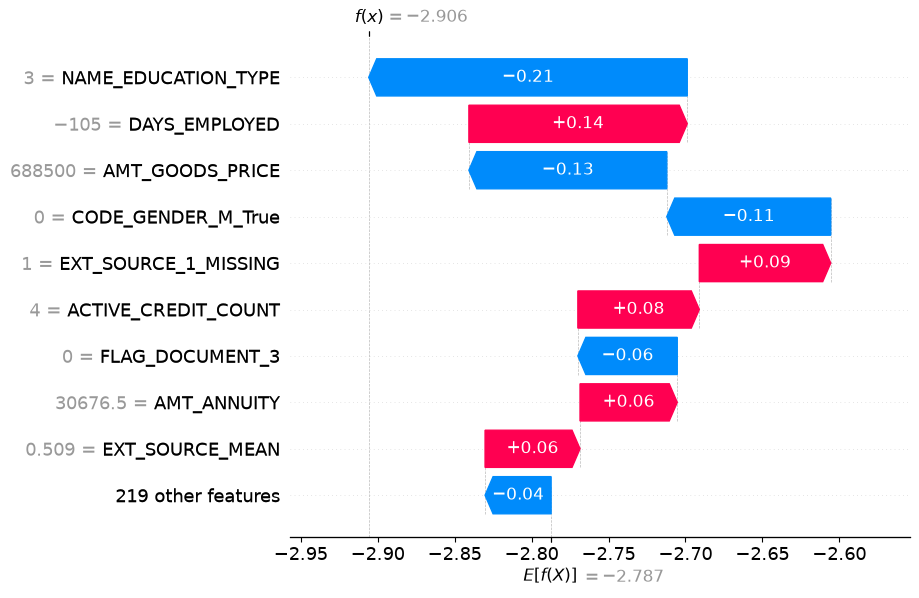

In [29]:
shap.plots.waterfall(selected_shap[2], max_display=10)

# 5.Top four adverse-action factors

In [30]:
high_factors = pd.DataFrame({"Feature": selected.columns,"Value": selected.iloc[0],"SHAP": selected_shap[0].values})
top_four = high_factors[high_factors["SHAP"] > 0].sort_values("SHAP", ascending=False).head(4)

top_four

,Feature,Value,SHAP
EXT_SOURCE_MEAN,EXT_SOURCE_MEAN,0.248996,1.486149
CREDIT_TERM,CREDIT_TERM,0.048840,0.309816
EXT_SOURCE_3,EXT_SOURCE_3,0.068251,0.268950
AMT_GOODS_PRICE,AMT_GOODS_PRICE,450000.000000,0.183927


In [31]:
print("Main reasons for decline:")

for row in top_four.itertuples():
    print(f"- {row.Feature}: value = {row.Value:.3f}")

Main reasons for decline:
- EXT_SOURCE_MEAN: value = 0.249
- CREDIT_TERM: value = 0.049
- EXT_SOURCE_3: value = 0.068
- AMT_GOODS_PRICE: value = 450000.000


# 6. PSI For TOP 10 Features

In [33]:
def psi(expected, actual, bins=10):
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    
    expected_pct = np.histogram(expected, bins=edges)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=edges)[0] / len(actual)

    expected_pct = np.clip(expected_pct, 1e-6, None)
    actual_pct = np.clip(actual_pct, 1e-6, None)

    return np.sum((actual_pct - expected_pct)* np.log(actual_pct / expected_pct))

importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Importance", ascending=False)

top_features = importance.head(10)["Feature"]

X_train_imp = pd.DataFrame(
    imputer.transform(X_train),
    columns=X_train.columns
)

psi_table = pd.DataFrame({
    "Feature": top_features,
    "PSI": [
        psi(X_train_imp[col], X_test_imp[col])
        for col in top_features
    ]
})

psi_table["Flag"] = psi_table["PSI"] > 0.25
psi_table

,Feature,PSI,Flag
169,EXT_SOURCE_MEAN,0.000216,False
166,CREDIT_TERM,0.000257,False
183,CODE_GENDER_M_True,0.000000,False
5,AMT_GOODS_PRICE,0.000068,False
6,NAME_EDUCATION_TYPE,0.000049,False
9,DAYS_EMPLOYED,0.000238,False
109,EXT_SOURCE_1_MISSING,0.000000,False
4,AMT_ANNUITY,0.000275,False
200,NAME_FAMILY_STATUS_Married_True,0.000000,False
31,EXT_SOURCE_3,0.000322,False


# 7. Monitoring Dashboard

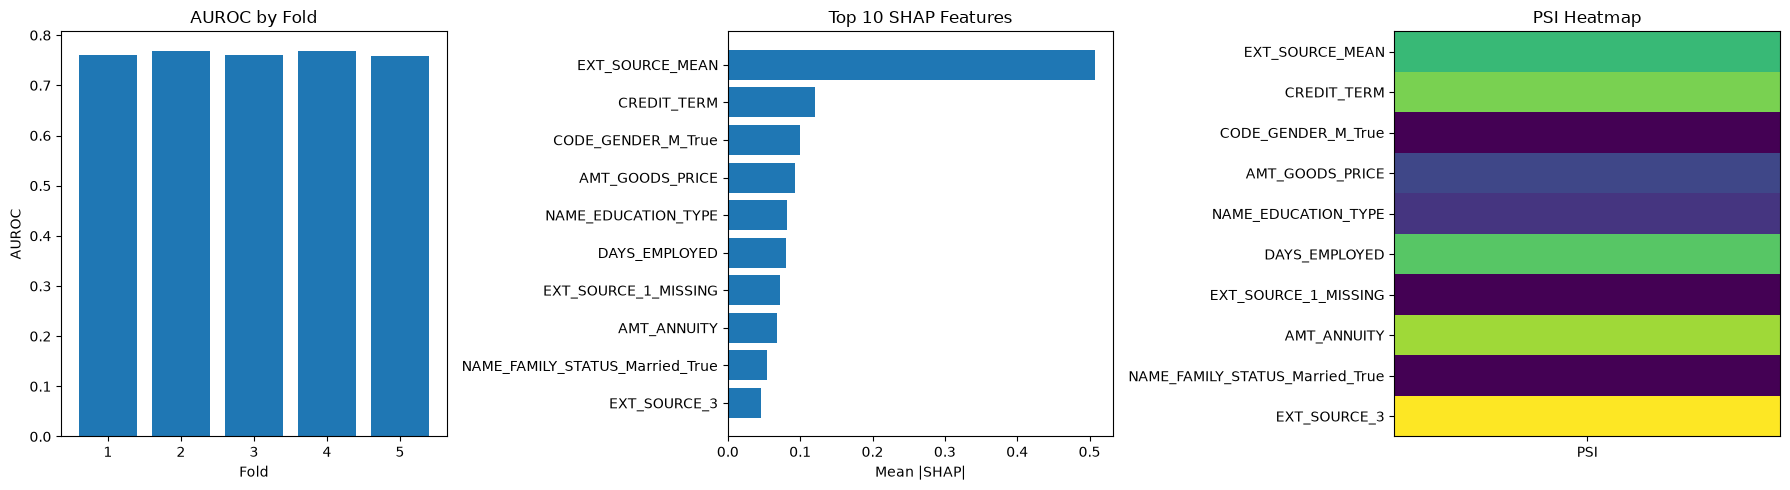

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1, 6), cv_scores)
axes[0].set_title("AUROC by Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("AUROC")

top_10 = importance.head(10).sort_values("Importance")
axes[1].barh(top_10["Feature"], top_10["Importance"])
axes[1].set_title("Top 10 SHAP Features")
axes[1].set_xlabel("Mean |SHAP|")

axes[2].imshow(psi_table[["PSI"]], aspect="auto")
axes[2].set_title("PSI Heatmap")
axes[2].set_xticks([0])
axes[2].set_xticklabels(["PSI"])
axes[2].set_yticks(range(len(psi_table)))
axes[2].set_yticklabels(psi_table["Feature"])

plt.tight_layout()
plt.show()